In [1]:
import pandas as pd

# ネット上のデータセットを直接読み込みます
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# カラム名（特徴量）を設定
column_names = ['妊娠回数', '血糖値', '血圧', '皮下脂肪厚', 'インスリン', 'BMI', '家系', '年齢', '結果']
df = pd.read_csv(url, names=column_names)

# データの最初の5行を表示して確認
df.head()

,妊娠回数,血糖値,血圧,皮下脂肪厚,インスリン,BMI,家系,年齢,結果
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
from sklearn.model_selection import train_test_split

# 1. 特徴量（X）と正解ラベル（y）に分ける
# 「結果」以外の列をすべてXに、 「結果」列だけをyにする
X = df.drop('結果', axis=1)
y = df['結果']

# 2. 学習用（8割）とテスト用（2割）に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# データの数を確認
print(f"学習用データの数: {len(X_train)}件")
print(f"テスト用データの数: {len(X_test)}件")

学習用データの数: 614件
テスト用データの数: 154件


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# モデルの定義
model = Sequential([
    # 入力層（特徴量が8個あるので input_dim=8）
    Dense(12, input_dim=8, activation='relu'), 
    # 中間層
    Dense(8, activation='relu'),
    # 出力層（二値分類なので 1つ。 0〜1の確率を出すために sigmoid を使う）
    Dense(1, activation='sigmoid')
])

# コンパイル（二値分類用の設定）
model.compile(loss='binary_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

# モデルの構造を表示
model.summary()

c:\Users\takes\Downloads\aidev (1)\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
%%time
# 学習の実施（100回繰り返します）
# validation_split=0.2 で学習データのうち2割を検証用に使いながら進めます
history = model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.2, verbose=1)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5316 - loss: 2.8250 - val_accuracy: 0.6585 - val_loss: 1.7886
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6130 - loss: 1.4413 - val_accuracy: 0.6667 - val_loss: 1.7614
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6130 - loss: 1.3442 - val_accuracy: 0.6423 - val_loss: 1.6192
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6212 - loss: 1.2698 - val_accuracy: 0.6667 - val_loss: 1.5878
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6334 - loss: 1.2363 - val_accuracy: 0.6667 - val_loss: 1.4420
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6171 - loss: 1.1296 - val_accuracy: 0.6260 - val_loss: 1.3421
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6314 - loss: 1.0648 - val_accuracy: 0.6504 - val_loss: 1.3015
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6354 - loss: 1.0328 - val_accuracy: 0.6260 - v

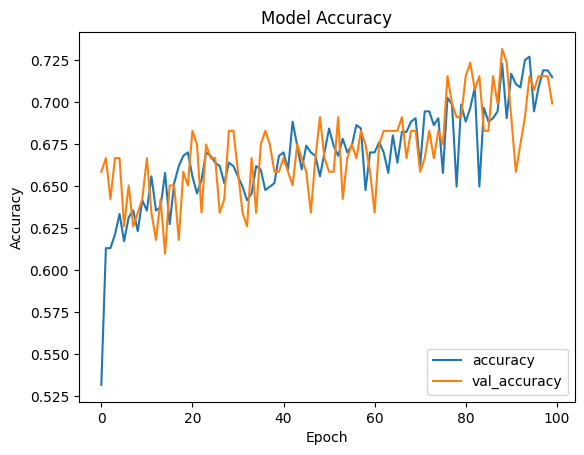

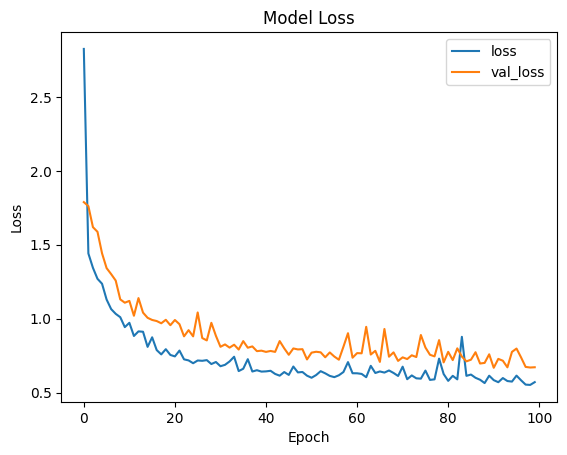

In [5]:
import matplotlib.pyplot as plt

# 正解率（Accuracy）の推移をグラフ表示
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# 誤差（Loss）の推移をグラフ表示
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [6]:
# 予測の実行（0.5より大きければ1、それ以外は0とする）
predictions = (model.predict(X_test) > 0.5).astype("int32")

# 評価結果の表示
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       107
           1       0.54      0.64      0.58        47

    accuracy                           0.72       154
   macro avg       0.68      0.70      0.69       154
weighted avg       0.74      0.72      0.73       154

